Fine-tune BERT to extract key entities from Canadian financial documents:
- `VENDOR` – Vendor/company name
- `AMOUNT` – Dollar amounts
- `DATE` – Document date  
- `INVOICE_NUM` – Invoice number
- `TAX` – HST/tax amounts

In [35]:
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import torch

from transformers import (
    BertTokenizerFast,
    BertForTokenClassification,
    TrainingArguments,
    Trainer,
    DataCollatorForTokenClassification
)
from datasets import Dataset as HFDataset
from seqeval.metrics import classification_report, f1_score

from sklearn.model_selection import train_test_split


print(f"PyTorch: {torch.__version__}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

PyTorch: 2.10.0+cu128
Device: cuda


In [36]:
import os
os.makedirs('bert_results', exist_ok=True)
print("bert_results/ folder created!")

bert_results/ folder created!


In [37]:
df = pd.read_csv('invoices_dataset.csv')

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nDocument type distribution:")
print(df['document_type'].value_counts())
print(f"\nAnomaly distribution:")
print(df['is_anomaly'].value_counts())

Shape: (10000, 12)
Columns: ['document_type', 'invoice_id', 'vendor_name', 'amount', 'date', 'invoice_number', 'tax_rate', 'tax_amount', 'line_items', 'invoice_text', 'is_anomaly', 'anomaly_type']

Document type distribution:
document_type
invoice    10000
Name: count, dtype: int64

Anomaly distribution:
is_anomaly
False    9000
True     1000
Name: count, dtype: int64


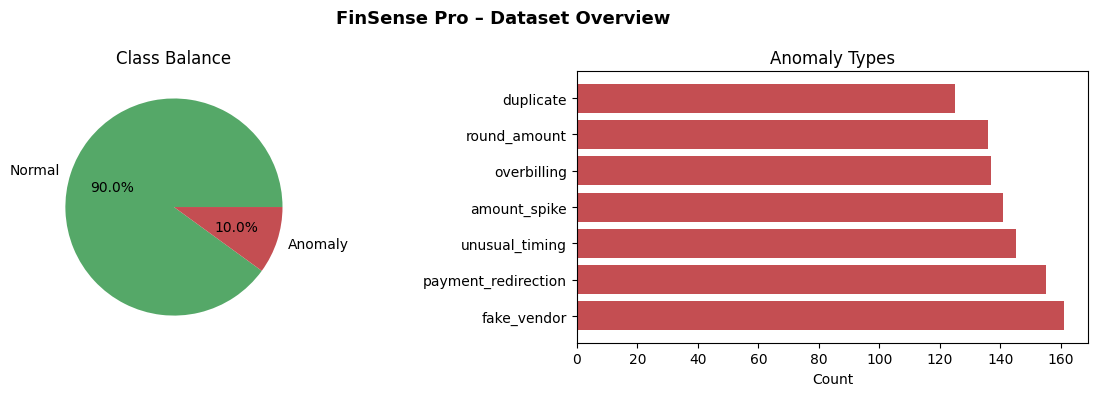

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

anomaly_counts = df['is_anomaly'].value_counts()
axes[0].pie(
    anomaly_counts.values,
    labels=['Normal', 'Anomaly'],
    autopct='%1.1f%%',
    colors=['#55A868', '#C44E52']
)
axes[0].set_title('Class Balance')

anomaly_types = df[df['is_anomaly'] == True]['anomaly_type'].value_counts()
axes[1].barh(anomaly_types.index, anomaly_types.values, color='#C44E52')
axes[1].set_title('Anomaly Types')
axes[1].set_xlabel('Count')

plt.suptitle('FinSense Pro – Dataset Overview', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('bert_results/eda_class_balance.png', dpi=150, bbox_inches='tight')  # ← ekle
plt.show()

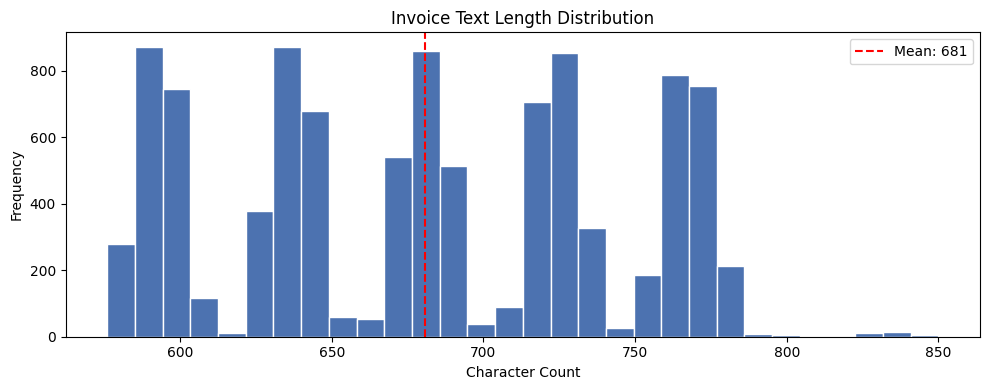

Min  : 576
Max  : 850
Mean : 681


In [39]:
df['text_length'] = df['invoice_text'].str.len()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df['text_length'], bins=30, color='#4C72B0', edgecolor='white')
ax.set_title('Invoice Text Length Distribution')
ax.set_xlabel('Character Count')
ax.set_ylabel('Frequency')

mean_len = df['text_length'].mean()
ax.axvline(mean_len, color='red', linestyle='--', label=f'Mean: {mean_len:.0f}')
ax.legend()
plt.tight_layout()
plt.savefig('bert_results/eda_text_length.png', dpi=150, bbox_inches='tight')  # ← buraya
plt.show()

print(f"Min  : {df['text_length'].min()}")
print(f"Max  : {df['text_length'].max()}")
print(f"Mean : {df['text_length'].mean():.0f}")

In [40]:
normal = df[df['is_anomaly'] == False].iloc[0]
fraud  = df[df['is_anomaly'] == True].iloc[0]

print("=" * 55)
print("NORMAL INVOICE:")
print("=" * 55)
print(normal['invoice_text'])
print(f"\nVendor : {normal['vendor_name']}")
print(f"Amount : {normal['amount']}")
print(f"Date   : {normal['date']}")

print("\n" + "=" * 55)
print(f"FRAUD INVOICE ({fraud['anomaly_type']}):")
print("=" * 55)
print(fraud['invoice_text'])
print(f"\nVendor : {fraud['vendor_name']}")
print(f"Amount : {fraud['amount']}")

NORMAL INVOICE:
INVOICE
Invoice #: INV-814473
Date: May 22, 2026

Bill To:
Simrat Enterprises
123 Maple Avenue, Suite 400
Toronto, ON M5V 2T6

Vendor:
Vancouver Logistics Inc
6624 Michael Keys Apt. 617, Port Kimberly, MB G8M2K2

Description                          Amount
----------------------------------------
Maintenance Fee                     $514.85
Shipping Charges                    $174.36

----------------------------------------
Subtotal                              $1,455.22
HST (13%)                               $189.18
Total Due                               $1,644.40

Thank you for your business!

Vendor : Vancouver Logistics Inc
Amount : 1455.22
Date   : 2026-05-22

FRAUD INVOICE (amount_spike):
INVOICE
Invoice #: INV-974920
Date: May 22, 2026

Bill To:
Simrat Enterprises
123 Maple Avenue, Suite 400
Toronto, ON M5V 2T6

Vendor:
Ottawa Consulting Group
6888 Maria Junctions Suite 209, Rioston, QC X6H 2B2

Description                          Amount
----------------------

## BIO Tagging

We assign a label to every word in the text:

| Word | Label |
|------|-------|
| Vancouver | B-VENDOR |
| Logistics | I-VENDOR |
| Inc | I-VENDOR |
| INV-373710 | B-INVOICE_NUM |
| May | B-DATE |
| 22, | I-DATE |
| 2026 | I-DATE |
| $189.18 | B-TAX |
| $1,455.22 | B-AMOUNT |
| INVOICE | O |

**B** = Beginning of entity  
**I** = Inside (continuation) of entity  
**O** = Outside (not an entity)

In [41]:
LABEL2ID = {
    'O': 0,
    'B-VENDOR': 1,      'I-VENDOR': 2,
    'B-AMOUNT': 3,      'I-AMOUNT': 4,
    'B-DATE': 5,        'I-DATE': 6,
    'B-INVOICE_NUM': 7, 'I-INVOICE_NUM': 8,
    'B-TAX': 9,         'I-TAX': 10,
}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}

print("Label mapping:")
for label, idx in LABEL2ID.items():
    print(f"  {idx} → {label}")

Label mapping:
  0 → O
  1 → B-VENDOR
  2 → I-VENDOR
  3 → B-AMOUNT
  4 → I-AMOUNT
  5 → B-DATE
  6 → I-DATE
  7 → B-INVOICE_NUM
  8 → I-INVOICE_NUM
  9 → B-TAX
  10 → I-TAX


In [42]:
def bio_tag_text(text, vendor_name=None, date=None):
    """
    Assigns BIO labels to each word in the text.

    Example:
    Vancouver → B-VENDOR
    Logistics → I-VENDOR
    Inc       → I-VENDOR
    $189.18   → B-TAX
    """
    words = text.split()
    labels = ['O'] * len(words)

    def tag_span(entity_text, bio_label):
        if not entity_text or pd.isna(entity_text):
            return
        entity_words = str(entity_text).split()
        n = len(entity_words)
        for i in range(len(words) - n + 1):
            if [w.strip('.,;:') for w in words[i:i+n]] == entity_words:
                labels[i] = f'B-{bio_label}'
                for j in range(1, n):
                    labels[i+j] = f'I-{bio_label}'
                break

    tag_span(vendor_name, 'VENDOR')

    amount_pattern = re.compile(r'\$[\d,]+\.\d{2}')
    inv_pattern    = re.compile(r'INV-\d+')

    first_amount_tagged = False

    for i, word in enumerate(words):
        clean = word.strip('.,;:')

        if inv_pattern.match(clean) and labels[i] == 'O':
            labels[i] = 'B-INVOICE_NUM'

        elif amount_pattern.fullmatch(clean) and labels[i] == 'O':
            context = ' '.join(words[max(0, i-5):i])
            if 'HST' in context or 'Tax' in context:
                labels[i] = 'B-TAX'
            elif not first_amount_tagged:
                labels[i] = 'B-AMOUNT'
                first_amount_tagged = True

    return words, labels


sample = df.iloc[0]
words, labels = bio_tag_text(
    sample['invoice_text'],
    vendor_name=sample['vendor_name'],
    date=sample['date']
)

print(f"{'Word':<25} {'Tag'}")
print("-" * 40)
for w, l in zip(words, labels):
    if l != 'O':
        print(f"{w:<25} {l}  ✓")
    else:
        print(f"{w:<25} {l}")

Word                      Tag
----------------------------------------
INVOICE                   O
Invoice                   O
#:                        O
INV-814473                B-INVOICE_NUM  ✓
Date:                     O
May                       O
22,                       O
2026                      O
Bill                      O
To:                       O
Simrat                    O
Enterprises               O
123                       O
Maple                     O
Avenue,                   O
Suite                     O
400                       O
Toronto,                  O
ON                        O
M5V                       O
2T6                       O
Vendor:                   O
Vancouver                 B-VENDOR  ✓
Logistics                 I-VENDOR  ✓
Inc                       I-VENDOR  ✓
6624                      O
Michael                   O
Keys                      O
Apt.                      O
617,                      O
Port                      O
Kimberly,       

In [43]:
SAMPLE_SIZE = 2000
df_sample = df.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)

tagged_data = []
for _, row in df_sample.iterrows():
    words, labels = bio_tag_text(
        row['invoice_text'],
        vendor_name=row.get('vendor_name'),
        date=row.get('date')
    )
    if len(words) > 0:
        tagged_data.append({'words': words, 'labels': labels})

print(f"Number of tagged documents: {len(tagged_data)}")

all_labels = [l for doc in tagged_data for l in doc['labels']]
label_counts = Counter(all_labels)
print("\nLabel distribution:")
for label, count in sorted(label_counts.items()):
    print(f"  {label:<20} {count}")

Number of tagged documents: 2000

Label distribution:
  B-AMOUNT             2000
  B-INVOICE_NUM        2000
  B-TAX                2000
  B-VENDOR             1964
  I-VENDOR             3928
  O                    107382


In [44]:
train_data, temp_data = train_test_split(tagged_data, test_size=0.30, random_state=42)
val_data, test_data   = train_test_split(temp_data,   test_size=0.50, random_state=42)

print(f"Train      : {len(train_data)} documents")
print(f"Validation : {len(val_data)} documents")
print(f"Test       : {len(test_data)} documents")

Train      : 1400 documents
Validation : 300 documents
Test       : 300 documents


In [45]:
MODEL_NAME = 'bert-base-uncased'
tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)
MAX_LEN = 128

print(f"Tokenizer loaded: {MODEL_NAME}")

Tokenizer loaded: bert-base-uncased


In [46]:
test_words = ['Vancouver', 'Logistics', 'Inc', '$189.18']
encoding = tokenizer(test_words, is_split_into_words=True)

print("Words    :", test_words)
print("Token IDs:", encoding['input_ids'])
print("Tokens   :", tokenizer.convert_ids_to_tokens(encoding['input_ids']))
print("Word IDs :", encoding.word_ids())

Words    : ['Vancouver', 'Logistics', 'Inc', '$189.18']
Token IDs: [101, 6930, 12708, 4297, 1002, 20500, 1012, 2324, 102]
Tokens   : ['[CLS]', 'vancouver', 'logistics', 'inc', '$', '189', '.', '18', '[SEP]']
Word IDs : [None, 0, 1, 2, 3, 3, 3, 3, None]


In [47]:
def tokenize_and_align_labels(examples):
    tokenized = tokenizer(
        examples['words'],
        truncation=True,
        max_length=MAX_LEN,
        is_split_into_words=True,
        padding='max_length'
    )

    aligned_labels = []
    for i, label_list in enumerate(examples['labels']):
        word_ids = tokenized.word_ids(batch_index=i)
        label_ids = []
        previous_word_id = None
        for word_id in word_ids:
            if word_id is None:
                label_ids.append(-100)
            elif word_id != previous_word_id:
                label_ids.append(LABEL2ID[label_list[word_id]])
            else:
                label_ids.append(-100)
            previous_word_id = word_id
        aligned_labels.append(label_ids)

    tokenized['labels'] = aligned_labels
    return tokenized

print("Tokenization function ready!")

Tokenization function ready!


In [48]:
def to_hf_dataset(data):
    return HFDataset.from_dict({
        'words':  [d['words']  for d in data],
        'labels': [d['labels'] for d in data]
    })

train_hf = to_hf_dataset(train_data)
val_hf   = to_hf_dataset(val_data)
test_hf  = to_hf_dataset(test_data)

train_tokenized = train_hf.map(tokenize_and_align_labels, batched=True)
val_tokenized   = val_hf.map(tokenize_and_align_labels,   batched=True)
test_tokenized  = test_hf.map(tokenize_and_align_labels,  batched=True)

print("Train tokenized :", len(train_tokenized))
print("Val tokenized   :", len(val_tokenized))
print("Test tokenized  :", len(test_tokenized))

Map:   0%|          | 0/1400 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Train tokenized : 1400
Val tokenized   : 300
Test tokenized  : 300


In [49]:
model = BertForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(LABEL2ID),
    id2label=ID2LABEL,
    label2id=LABEL2ID
)

print(f"Model loaded: {MODEL_NAME}")
print(f"Number of labels: {len(LABEL2ID)}")

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized be

Model loaded: bert-base-uncased
Number of labels: 11
Total parameters: 108,900,107


In [50]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=2)

    true_labels = [
        [ID2LABEL[l] for l in label if l != -100]
        for label in labels
    ]
    true_predictions = [
        [ID2LABEL[p] for p, l in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]

    report = classification_report(
        true_labels,
        true_predictions,
        output_dict=True
    )
    return {
        'f1':        report['weighted avg']['f1-score'],
        'precision': report['weighted avg']['precision'],
        'recall':    report['weighted avg']['recall'],
    }

print("Metrics function ready!")

Metrics function ready!


In [51]:
training_args = TrainingArguments(
    output_dir='./bert_ner_model',
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    warmup_steps=100,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    logging_steps=50,
    report_to='none'
)

data_collator = DataCollatorForTokenClassification(tokenizer)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

print("Trainer ready! Training can begin.")

Trainer ready! Training can begin.


In [52]:
print("Training started...")
train_result = trainer.train()
print("\nTraining complete!")
print(f"Training loss: {train_result.training_loss:.4f}")

Training started...


Epoch,Training Loss,Validation Loss,F1,Precision,Recall
1,1.314536,0.013152,0.996127,0.992344,1.000000
2,0.009963,0.009841,0.996127,0.992344,1.000000
3,0.008009,0.009144,0.996127,0.992344,1.000000
4,0.008894,0.008517,0.996127,0.992344,1.000000
5,0.007139,0.008884,0.996127,0.992344,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Training complete!
Training loss: 0.1617


In [53]:
log_history = trainer.state.log_history
with open('bert_results/training_summary.txt', 'w') as f:
    f.write("BERT NER Training Summary\n")
    f.write("=" * 40 + "\n")
    for log in log_history:
        if 'eval_f1' in log:
            f.write(f"Epoch {log['epoch']}: F1={log['eval_f1']:.4f}, Val Loss={log['eval_loss']:.4f}\n")
print("Saved: training_summary.txt")

Saved: training_summary.txt


In [54]:
predictions_output = trainer.predict(test_tokenized)
preds = np.argmax(predictions_output.predictions, axis=2)
labels_array = predictions_output.label_ids

true_labels = [
    [ID2LABEL[l] for l in label if l != -100]
    for label in labels_array
]
true_preds = [
    [ID2LABEL[p] for p, l in zip(pred, label) if l != -100]
    for pred, label in zip(preds, labels_array)
]

with open('bert_results/classification_report.txt', 'w') as f:
    f.write(classification_report(true_labels, true_preds))
print("Saved: classification_report.txt")

print("=== TEST SET RESULTS ===")
print(classification_report(true_labels, true_preds))

Saved: classification_report.txt
=== TEST SET RESULTS ===
              precision    recall  f1-score   support

      AMOUNT       1.00      1.00      1.00       300
 INVOICE_NUM       1.00      1.00      1.00       300
      VENDOR       0.99      1.00      0.99       297

   micro avg       1.00      1.00      1.00       897
   macro avg       1.00      1.00      1.00       897
weighted avg       1.00      1.00      1.00       897



In [ ]:
def extract_entities(text):
    model.eval()
    words = text.split()

    encoding = tokenizer(
        words,
        is_split_into_words=True,
        return_tensors='pt',
        truncation=True,
        max_length=128
    )

    # Get word_ids before moving tensors to device, as it converts to dict
    word_ids = encoding.word_ids()

    # Move all tensors in the encoding dictionary to the correct device
    encoding = {k: v.to(device) for k, v in encoding.items()}

    with torch.no_grad():
        outputs = model(**encoding)

    predictions = torch.argmax(outputs.logits, dim=2)[0].tolist()

    entities = {}
    current_entity = None
    current_words = []

    word_preds = {}
    for token_id, word_id in enumerate(word_ids):
        if word_id is not None and word_id not in word_preds:
            word_preds[word_id] = ID2LABEL[predictions[token_id]]

    for word_id, label in sorted(word_preds.items()):
        if label.startswith('B-'):
            if current_entity:
                entities[current_entity] = ' '.join(current_words)
            current_entity = label[2:]
            current_words = [words[word_id]]
        elif label.startswith('I-') and current_entity:
            current_words.append(words[word_id])
        else:
            if current_entity:
                entities[current_entity] = ' '.join(current_words)
            current_entity = None
            current_words = []

    if current_entity:
        entities[current_entity] = ' '.join(current_words)

    return entities


# ── A new invoice the model has never seen. ──
new_invoice = """INVOICE
Invoice #: INV-999888
Date: April 10, 2026

Bill To:
Simrat Enterprises
123 Maple Avenue, Toronto, ON

Vendor:
Ottawa Consulting Group
456 Bay Street, ON

Description                Amount
-----------------------------------
Consulting Services        $3,200.00
Office Equipment           $800.00

-----------------------------------
Subtotal                   $4,000.00
HST (13%)                  $520.00
===================================
Total Due                  $4,520.00

Thank you for your business!"""

print("INPUT:")
print(new_invoice)
print("\nEXTRACTED ENTITIES:")
entities = extract_entities(new_invoice)
for entity_type, value in entities.items():
    print(f"  {entity_type:<15} → {value}")

with open('bert_results/inference_example.txt', 'w') as f:
    f.write("INPUT:\n")
    f.write(new_invoice)
    f.write("\n\nEXTRACTED ENTITIES:\n")
    for entity_type, value in entities.items():
        f.write(f"  {entity_type:<15} → {value}\n")
print("Saved: inference_example.txt")

INPUT:
INVOICE
Invoice #: INV-999888
Date: April 10, 2026

Bill To:
Simrat Enterprises
123 Maple Avenue, Toronto, ON

Vendor:
Northern Supply Co
456 Bay Street, Vancouver, BC

Description                Amount
-----------------------------------
Consulting Services        $3,200.00
Office Equipment           $800.00

-----------------------------------
Subtotal                   $4,000.00
HST (13%)                  $520.00
Total Due                  $4,520.00

Thank you for your business!

EXTRACTED ENTITIES:
  INVOICE_NUM     → INV-999888
  VENDOR          → Vancouver,
  AMOUNT          → $3,200.00
Saved: inference_example.txt
